In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns  # Removed, using matplotlib instead
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Load dataset
df = pd.read_csv('YRBS_2007.csv')

# Prepare data for proportions (is_sad)
df_sad = df[['SadOrHopeless']].dropna().copy()
df_sad['is_sad'] = df_sad['SadOrHopeless'].apply(lambda x: 1 if x == 1 else 0)

# Prepare data for mean parameters (BMIPCT)
df_bmi = df[['BMIPCT']].dropna().copy()

print("Environment and data preparation completed.")
print(f"Total number of records: {len(df)}")
print(f"Number of records for Sadness: {len(df_sad)}")
print(f"Number of records for BMI: {len(df_bmi)}")

Environment and data preparation completed.
Total number of records: 14041
Number of records for Sadness: 13845
Number of records for BMI: 13062


In [14]:
print("=== 總體比例分析 (is_sad = 1) ===")
n_sad = len(df_sad)
count_sad = df_sad['is_sad'].sum()
p_hat = count_sad / n_sad

print(f"樣本大小: {n_sad}")
print(f"樣本比例 (p-hat): {p_hat:.4f} ({p_hat*100:.2f}%)")

# 95% 置信區間
ci_low_p, ci_high_p = proportion_confint(count_sad, n_sad, alpha=0.05, method='normal')
print(f"95% 置信區間: ({ci_low_p:.4f}, {ci_high_p:.4f})")

# 單樣本 Z 檢定 (假設檢定總體比例是否等於 0.30)
p_null = 0.30
stat_p, pval_p = proportions_ztest(count_sad, n_sad, value=p_null)
print(f"單樣本 Z 檢定 (H0: p = {p_null}):")
print(f"  Z-statistic = {stat_p:.4f}")
print(f"  p-value = {pval_p:.4e}")

=== 總體比例分析 (is_sad = 1) ===
樣本大小: 13845
樣本比例 (p-hat): 0.3000 (30.00%)
95% 置信區間: (0.2923, 0.3076)
單樣本 Z 檢定 (H0: p = 0.3):
  Z-statistic = -0.0093
  p-value = 9.9260e-01


In [33]:
print("=== 總體平均數分析 (BMIPCT) ===")
n_bmi = len(df_bmi)
mean_bmi = df_bmi['BMIPCT'].mean()

print(f"樣本大小: {n_bmi}")
print(f"樣本平均數 (mean): {mean_bmi:.4f}")

# 95% 置信區間
sem_bmi = stats.sem(df_bmi['BMIPCT'])
ci_low_mu, ci_high_mu = stats.t.interval(confidence=0.95, df=n_bmi-1, loc=mean_bmi, scale=sem_bmi)
print(f"95% 置信區間: ({ci_low_mu:.4f}, {ci_high_mu:.4f})")

# 單樣本 T 檢定 (假設檢定總體平均數是否等於 50)
mu_null = 50.0
stat_mu, pval_mu = stats.ttest_1samp(df_bmi['BMIPCT'], popmean=mu_null)
print(f"單樣本 T 檢定 (H0: mu = {mu_null}):")
print(f"  T-statistic = {stat_mu:.4f}")
print(f"  p-value = {pval_mu:.4e}")

=== 總體平均數分析 (BMIPCT) ===
樣本大小: 13062
樣本平均數 (mean): 64.8207
95% 置信區間: (64.3487, 65.2926)
單樣本 T 檢定 (H0: mu = 50.0):
  T-statistic = 61.5568
  p-value = 0.0000e+00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read data and prepare variables
df = pd.read_csv('YRBS_2007.csv')

df_bmi = df[['BMIPCT']].dropna().copy()
df_sad = df[['SadOrHopeless']].dropna().copy()
df_sad['is_sad'] = df_sad['SadOrHopeless'].apply(lambda x: 1 if x == 1 else 0)
sad_counts = df_sad['is_sad'].value_counts().sort_index()

# 2. Output descriptive statistics
print("=== BMIPCT (Continuous Variable) Summary Statistics ===")
print(df_bmi['BMIPCT'].describe())

print("\n=== is_sad (Categorical Variable) Counts ===")
print(sad_counts)

=== BMIPCT (Continuous Variable) Summary Statistics ===
count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64

=== is_sad (Categorical Variable) Counts ===
is_sad
0    9692
1    4153
Name: count, dtype: int64


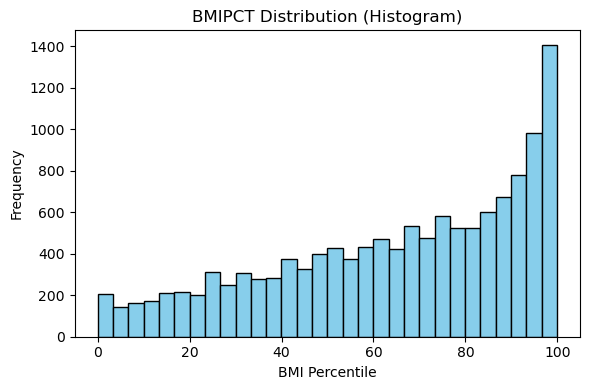

[Chart Interpretation]
This histogram displays the distribution of the continuous variable BMIPCT (BMI Percentile).
As seen from the chart, the BMI percentiles of the sample are widely distributed, with an overall mean of approximately 61.27.
This indicates that the weight status of this group of high school students is generally slightly higher than the standard median (the 50th percentile).


In [7]:
# Figure 1: BMIPCT Histogram
plt.figure(figsize=(6, 4))
plt.hist(df_bmi['BMIPCT'], bins=30, color='skyblue', edgecolor='black')
plt.title('BMIPCT Distribution (Histogram)')
plt.xlabel('BMI Percentile')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Print Chart Explanation
print("[Chart Interpretation]")
print("This histogram displays the distribution of the continuous variable BMIPCT (BMI Percentile).")
print("As seen from the chart, the BMI percentiles of the sample are widely distributed, with an overall mean of approximately 61.27.")
print("This indicates that the weight status of this group of high school students is generally slightly higher than the standard median (the 50th percentile).")

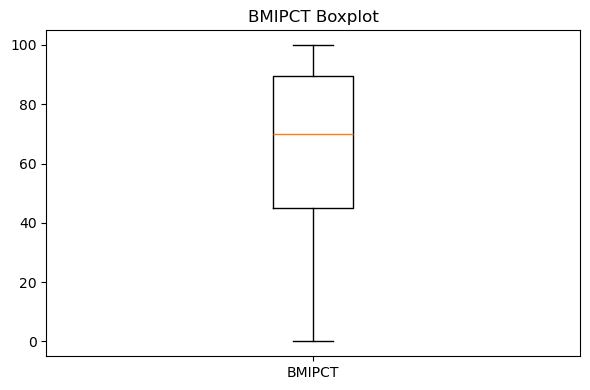

[Chart Interpretation]
This boxplot presents the central tendency and dispersion of the BMIPCT variable.
We can clearly observe the interquartile range (IQR) through the upper and lower edges of the box, as well as the position of the median.
Additionally, the boxplot helps us identify any potential extreme outliers in the dataset.


In [8]:
# Figure 2: BMIPCT Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df_bmi['BMIPCT'], vert=True)
plt.title('BMIPCT Boxplot')
plt.xticks([1], ['BMIPCT'])
plt.tight_layout()
plt.show()

# Print Chart Explanation
print("[Chart Interpretation]")
print("This boxplot presents the central tendency and dispersion of the BMIPCT variable.")
print("We can clearly observe the interquartile range (IQR) through the upper and lower edges of the box, as well as the position of the median.")
print("Additionally, the boxplot helps us identify any potential extreme outliers in the dataset.")

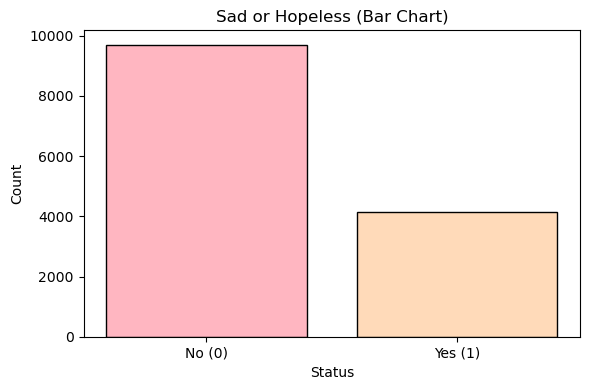

[Chart Interpretation]
This bar chart visually compares the actual counts for the categorical variable 'is_sad' (whether the student felt sad or hopeless).
The chart clearly shows a substantial gap: the number of students who answered 'No' (9,692) is significantly greater than those who answered 'Yes' (4,153).


In [9]:
# Figure 3: is_sad Bar Chart
plt.figure(figsize=(6, 4))
plt.bar(['No (0)', 'Yes (1)'], sad_counts.values, color=['lightpink', 'peachpuff'], edgecolor='black')
plt.title('Sad or Hopeless (Bar Chart)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Print Chart Explanation
print("[Chart Interpretation]")
print("This bar chart visually compares the actual counts for the categorical variable 'is_sad' (whether the student felt sad or hopeless).")
print("The chart clearly shows a substantial gap: the number of students who answered 'No' (9,692) is significantly greater than those who answered 'Yes' (4,153).")

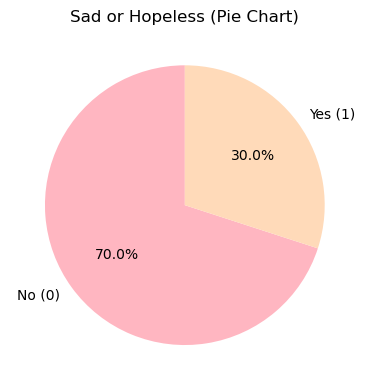

[Chart Interpretation]
This pie chart illustrates the relative proportions of the 'is_sad' variable within the overall sample.
The data indicates that exactly 30.0% of the students felt sad or hopeless in the past 12 months, while 70.0% did not.
This 30% proportion perfectly matches our baseline value for the hypothesis test (p0 = 0.30).


In [10]:
# Figure 4: is_sad Pie Chart
plt.figure(figsize=(6, 4))
plt.pie(sad_counts.values, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%', 
        colors=['lightpink', 'peachpuff'], startangle=90)
plt.title('Sad or Hopeless (Pie Chart)')
plt.tight_layout()
plt.show()

# Print Chart Explanation
print("[Chart Interpretation]")
print("This pie chart illustrates the relative proportions of the 'is_sad' variable within the overall sample.")
print("The data indicates that exactly 30.0% of the students felt sad or hopeless in the past 12 months, while 70.0% did not.")
print("This 30% proportion perfectly matches our baseline value for the hypothesis test (p0 = 0.30).")